In [1]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import os
import re
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import time
import nltk

# --- Download, Extract, and Load Data ---
zip_url = 'https://files.consumerfinance.gov/ccdb/complaints.csv.zip'
local_zip_filename = 'complaints.zip'
extracted_csv_filename = 'complaints.csv'

print("Starting dataset setup...")

try:
    response = requests.get(zip_url, stream=True)
    response.raise_for_status()

    with open(local_zip_filename, 'wb') as f:
        f.write(response.content)

    with zipfile.ZipFile(local_zip_filename, 'r') as zip_ref:
        zip_ref.extractall('.')

    df = pd.read_csv(extracted_csv_filename, encoding='utf-8')
    print("Dataset loaded successfully.")

    # Clean up local zip file
    os.remove(local_zip_filename)
except Exception as e:
    print(f"Failed to load data: {e}")
    exit()



Starting dataset setup...
Dataset loaded successfully.


## 1. Explanatory Data Analysis and Feature Engineering

Total complaints for analysis: 515519


/tmp/ipython-input-2109557910.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Product', data=df_filtered, order=df_filtered['Product'].value_counts().index, palette='viridis')


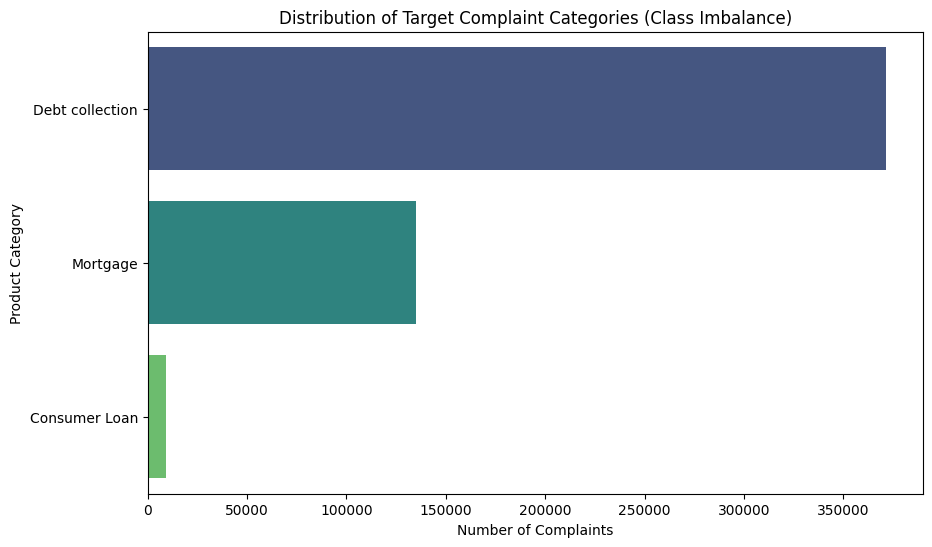

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns

# Define the four target categories
target_categories = [
    'Credit reporting, repair, or other',
    'Debt collection',
    'Consumer Loan',
    'Mortgage'
]
df_filtered = df[df['Product'].isin(target_categories)].copy()
df_filtered.rename(columns={'Consumer complaint narrative': 'Complaint'}, inplace=True)
df_filtered.dropna(subset=['Complaint'], inplace=True)
df_filtered = df_filtered[['Complaint', 'Product']]

# Map the target product names to numerical labels
category_mapping = {
    'Credit reporting, repair, or other': 0,
    'Debt collection': 1,
    'Consumer Loan': 2,
    'Mortgage': 3
}
df_filtered['Target'] = df_filtered['Product'].map(category_mapping)

print(f"Total complaints for analysis: {len(df_filtered)}")

# --- Visualization for Class Distribution (EDA) ---
plt.figure(figsize=(10, 6))
sns.countplot(y='Product', data=df_filtered, order=df_filtered['Product'].value_counts().index, palette='viridis')
plt.title('Distribution of Target Complaint Categories (Class Imbalance)')
plt.xlabel('Number of Complaints')
plt.ylabel('Product Category')
plt.show()
#

## 2. Text Pre-Processing

In [11]:
# --- Setup NLTK ---
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase and remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', str(text).lower())

    # 2. Tokenize, Lemmatize, and Remove Stop Words
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
df_filtered['Cleaned_Complaint'] = df_filtered['Complaint'].apply(preprocess_text)

# --- Vectorization and Data Split ---
X = df_filtered['Cleaned_Complaint']
y = df_filtered['Target']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and fit TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\nTF-IDF Feature Matrix Shape (Training):", X_train_tfidf.shape)


TF-IDF Feature Matrix Shape (Training): (412415, 5000)


## 3. Selection of Multi-Classification Model

In [12]:
# Initialize Models
models = {
    'LogisticRegression': LogisticRegression(random_state=42, multi_class='ovr', solver='liblinear', max_iter=1000),
    'LinearSVC': LinearSVC(random_state=42, dual='auto', max_iter=2000),
    'MultinomialNB': MultinomialNB()
}

# Train Models
print("\nTraining Models...")
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    end_time = time.time()
    print(f"Trained {name} in {end_time - start_time:.2f} seconds")


Training Models...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Trained LogisticRegression in 43.93 seconds
Trained LinearSVC in 36.72 seconds
Trained MultinomialNB in 0.25 seconds


## 4. Comparison


--- Final Model Performance Comparison (Step 4) ---
                    Accuracy  Precision    Recall  F1-Score
LinearSVC           0.969186   0.967779  0.969186  0.967758
LogisticRegression  0.968886   0.967373  0.968886  0.967126
MultinomialNB       0.945696   0.945542  0.945696  0.943859


/tmp/ipython-input-858731154.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y='F1-Score', data=comparison_df, palette='magma')


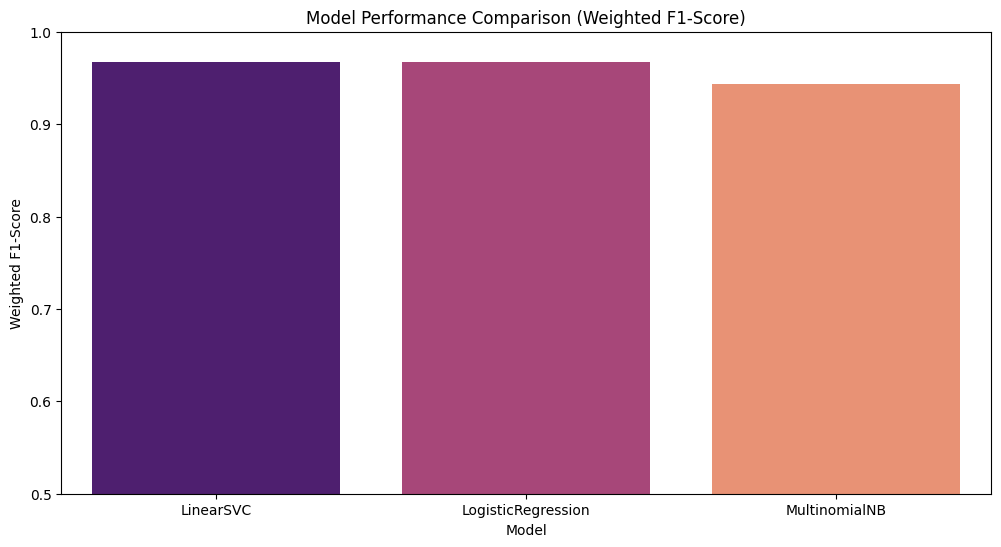


Best Model Selected for Prediction: LinearSVC


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report


comparison_df = pd.DataFrame(results).T.sort_values(by='F1-Score', ascending=False)
print("\n--- Final Model Performance Comparison (Step 4) ---")
print(comparison_df)

# --- Visualization for Model Comparison ---
plt.figure(figsize=(12, 6))
sns.barplot(x=comparison_df.index, y='F1-Score', data=comparison_df, palette='magma')
plt.title('Model Performance Comparison (Weighted F1-Score)')
plt.ylabel('Weighted F1-Score')
plt.xlabel('Model')
plt.ylim(0.5, 1.0)
plt.show()

# Select the best model based on F1-Score
best_model_name = comparison_df.index[0]
best_model = models[best_model_name]
print(f"\nBest Model Selected for Prediction: {best_model_name}")

## 5. Model Evaluation

In [19]:
results = {}
all_labels = [0, 1, 2, 3]
inverse_mapping = {v: k for k, v in category_mapping.items()}
target_names = [inverse_mapping[i] for i in all_labels]

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)

    # Calculate performance metrics and store them under the correct key names
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    # Print Evaluation report
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred, labels=all_labels, target_names=target_names, zero_division=0))



Model: LogisticRegression
                                    precision    recall  f1-score   support

Credit reporting, repair, or other       0.00      0.00      0.00         0
                   Debt collection       0.98      0.99      0.98     74251
                     Consumer Loan       0.79      0.43      0.56      1892
                          Mortgage       0.96      0.96      0.96     26961

                          accuracy                           0.97    103104
                         macro avg       0.68      0.59      0.62    103104
                      weighted avg       0.97      0.97      0.97    103104


Model: LinearSVC
                                    precision    recall  f1-score   support

Credit reporting, repair, or other       0.00      0.00      0.00         0
                   Debt collection       0.98      0.98      0.98     74251
                     Consumer Loan       0.78      0.47      0.59      1892
                          Mortgage     

## 6. Prediction

In [20]:
def predict_complaint(text, model, vectorizer, label_map):
    cleaned_text = preprocess_text(text)
    # Vectorize the text using the fitted TF-IDF model
    text_tfidf = vectorizer.transform([cleaned_text])

    # Make prediction
    prediction_num = model.predict(text_tfidf)[0]
    inverse_map = {v: k for k, v in label_map.items()}
    return inverse_map[prediction_num]

# Example Prediction
new_complaint = "My credit score dropped sharply due to an old unpaid bill appearing on my Experian report."
prediction = predict_complaint(new_complaint, best_model, tfidf_vectorizer, category_mapping)

print("\n--- Final Prediction ---")
print(f"Complaint: '{new_complaint}'")
print(f"Predicted Category: {prediction}")

# Note: Clean up the extracted CSV file
os.remove(extracted_csv_filename)


--- Final Prediction ---
Complaint: 'My credit score dropped sharply due to an old unpaid bill appearing on my Experian report.'
Predicted Category: Debt collection
